In [29]:
import numpy as np 
import matplotlib.pyplot as plt
import nibabel as nib

from dmipy.signal_models import sphere_models, cylinder_models, gaussian_models
from dmipy.core.acquisition_scheme import acquisition_scheme_from_bvalues

In [30]:
bvalues = np.loadtxt('../data/grad_files/bvals_verdict.txt')  # given in s/mm^2
bvalues_SI = bvalues * 1e9  # now given in SI units as s/m^2
gradient_directions = np.loadtxt('../data/grad_files/bvecs_verdict.txt')  # on the unit sphere

# The delta and Delta times we know from the HCP documentation in seconds
delta = np.loadtxt('../data/grad_files/smalldelta_verdict.txt') * 1e-3  # in seconds 
Delta = np.loadtxt('../data/grad_files/delta_verdict.txt') * 1e-3  # in seconds

# The acquisition scheme we use in the toolbox is then created as follows:
acq_scheme = acquisition_scheme_from_bvalues(bvalues_SI, gradient_directions.T, delta, Delta)

In [31]:
sphere = sphere_models.S4SphereGaussianPhaseApproximation(diffusion_constant=2e-9)
ball = gaussian_models.G1Ball()
stick = cylinder_models.C1Stick()
stick.spherical_mean(acq_scheme, lambda_par=2e-9)

array([0.99999933, 0.94310586, 0.74682413, 0.4410407 , 0.36160815,
       0.50434356])

In [32]:
from dmipy.core.modeling_framework import MultiCompartmentModel
verdict_mod = MultiCompartmentModel(models=[sphere, ball, stick])
verdict_mod.set_fixed_parameter('G1Ball_1_lambda_iso', 2e-9)
verdict_mod.set_fixed_parameter('C1Stick_1_lambda_par', 8e-9)
verdict_mod.parameter_names

We highly recommend installing numba for faster function execution and model fitting.
We highly recommend installing pathos to take advantage of multicore processing.


['S4SphereGaussianPhaseApproximation_1_diameter',
 'C1Stick_1_mu',
 'partial_volume_0',
 'partial_volume_1',
 'partial_volume_2']

In [33]:
data_verdict = nib.load('../data/test_images/BallSphereAstrosticks_fixed.nii.gz').get_fdata()
mask_verdict = nib.load('../data/test_images/BallSphereAstrosticks_fixed_mask.nii.gz').get_fdata()

In [93]:
verdict_fit = verdict_mod.fit(acq_scheme, data=data_verdict, mask=mask_verdict)

Setup brute2fine optimizer in 3.9930837154388428 seconds
Fitting of 1000 voxels complete in 55.64977312088013 seconds.
Average of 0.055649773120880125 seconds per voxel.


In [89]:
params = verdict_fit.fitted_parameters
radius = 0.5 * params['S4SphereGaussianPhaseApproximation_1_diameter'] * 1e9
f_ic = params['partial_volume_0']
f_ees = params['partial_volume_1']

In [90]:
params_gt = nib.load('../data/test_images/BallSphereAstrosticks_fixed_params.nii.gz').get_fdata()
radius_gt = params_gt[..., 1]
f_ic_gt = params_gt[..., 4]
f_ees_gt = params_gt[..., 3]

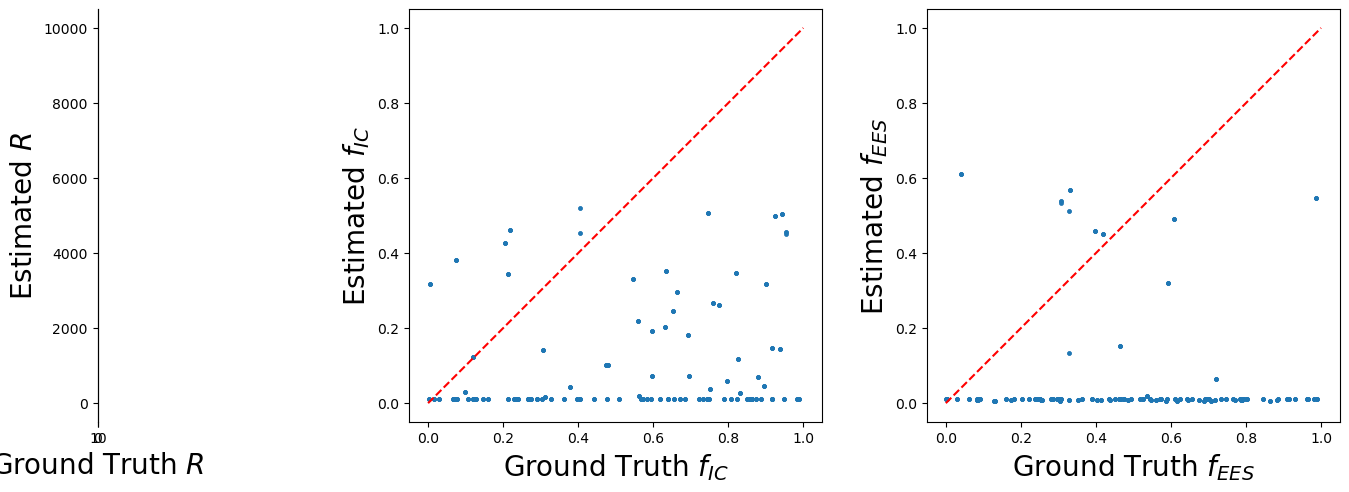

In [ ]:

limits = [[0, 15], [0, 1], [0, 1]]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Parameters to plot (Ground truth and estimated values)
params_to_plot = [
    (radius_gt, radius, '$R$'),
    (f_ic_gt, f_ic, '$f_{IC}$'),
    (f_ees_gt, f_ees, '$f_{EES}$')
]

# Loop through axes and parameters to plot
for ax, (gt, est, label), lim in zip(axes, params_to_plot, limits):
    ax.scatter(gt, est, s=5, alpha=0.5)
    ax.plot(lim, lim, 'r--')
    ax.set_xlabel(f'Ground Truth {label}', fontsize=20)
    ax.set_ylabel(f'Estimated {label}', fontsize=20)
    
    # Apply the same limit for both axes
    ax.set_xlim(lim)  # x-axis limit
    ax.set_ylim(lim)  # y-axis limit
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

In [92]:
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error

# Initialize lists to store results
mse_values = []
bias_values = []
variance_values = []
pearson_values = []

groundtruth_values = [radius_gt, f_ic_gt, f_ees_gt]
estimated_values = [0.5 * params['S4SphereGaussianPhaseApproximation_1_diameter'], f_ic, f_ees]

# Compute metrics for each parameter
for gt, est in zip(groundtruth_values, estimated_values):
    gt_flat = gt.flatten()
    est_flat = est.flatten()

    # MSE
    mse = mean_squared_error(gt_flat, est_flat)

    # Bias (Mean Difference)
    bias = np.mean(est_flat - gt_flat)

    # Variance (of the estimation error)
    variance = np.var(est_flat - gt_flat)

    # Pearson Correlation Coefficient
    pearson_corr, _ = pearsonr(gt_flat, est_flat)

    # Store results
    mse_values.append(mse)
    bias_values.append(bias)
    variance_values.append(variance)
    pearson_values.append(pearson_corr)

param_names = ['Radius', '$f_{IC}$', '$f_{EES}$']
# Display results
for i, param in enumerate(param_names):
    print(f"Parameter: {param}")
    print(f"  MSE: {mse_values[i]:.6f}")
    print(f"  Bias: {bias_values[i]:.6f}")
    print(f"  Variance: {variance_values[i]:.6f}")
    print(f"  Pearson Correlation: {pearson_values[i]:.6f}\n")


Parameter: Radius
  MSE: 84.937117
  Bias: -8.059135
  Variance: 19.987455
  Pearson Correlation: 0.043688

Parameter: $f_{IC}$
  MSE: 0.288535
  Bias: -0.434167
  Variance: 0.100034
  Pearson Correlation: 0.124390

Parameter: $f_{EES}$
  MSE: 0.289075
  Bias: -0.439120
  Variance: 0.096249
  Pearson Correlation: -0.061029



In [98]:
microtorch_estimates = nib.load('../results/params_data.nii.gz').get_fdata()
microtorch_radius = microtorch_estimates[..., 0]
microtorch_f_ic = microtorch_estimates[..., 1]
microtorch_f_ees = microtorch_estimates[..., 2]


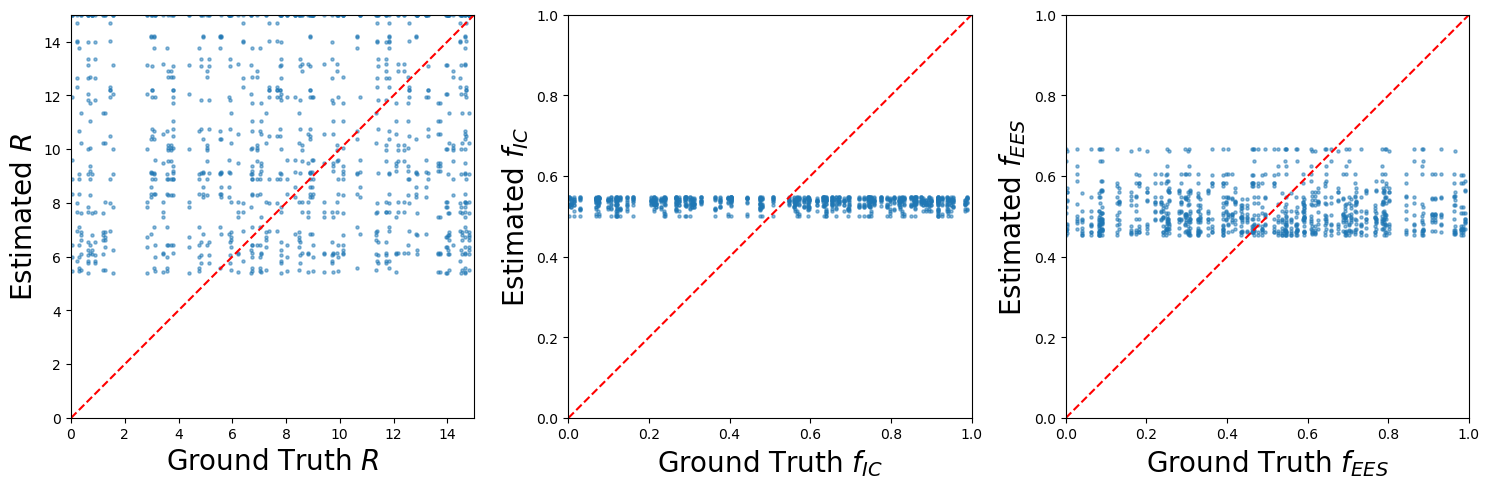

In [99]:
limits = [[0, 15], [0, 1], [0, 1]]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Parameters to plot (Ground truth and estimated values)
params_to_plot = [
    (radius_gt, microtorch_radius, '$R$'),
    (f_ic_gt, microtorch_f_ic, '$f_{IC}$'),
    (f_ees_gt, microtorch_f_ees, '$f_{EES}$')
]

# Loop through axes and parameters to plot
for ax, (gt, est, label), lim in zip(axes, params_to_plot, limits):
    ax.scatter(gt, est, s=5, alpha=0.5)
    ax.plot(lim, lim, 'r--')
    ax.set_xlabel(f'Ground Truth {label}', fontsize=20)
    ax.set_ylabel(f'Estimated {label}', fontsize=20)
    
    # Apply the same limit for both axes
    ax.set_xlim(lim)  # x-axis limit
    ax.set_ylim(lim)  # y-axis limit
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

In [100]:
mse_values = []
bias_values = []
variance_values = []
pearson_values = []

groundtruth_values = [radius_gt, f_ic_gt, f_ees_gt]
estimated_values = [microtorch_radius, microtorch_f_ic, microtorch_f_ees]

# Compute metrics for each parameter
for gt, est in zip(groundtruth_values, estimated_values):
    gt_flat = gt.flatten()
    est_flat = est.flatten()

    # MSE
    mse = mean_squared_error(gt_flat, est_flat)

    # Bias (Mean Difference)
    bias = np.mean(est_flat - gt_flat)

    # Variance (of the estimation error)
    variance = np.var(est_flat - gt_flat)

    # Pearson Correlation Coefficient
    pearson_corr, _ = pearsonr(gt_flat, est_flat)

    # Store results
    mse_values.append(mse)
    bias_values.append(bias)
    variance_values.append(variance)
    pearson_values.append(pearson_corr)

param_names = ['Radius', '$f_{IC}$', '$f_{EES}$']
# Display results
for i, param in enumerate(param_names):
    print(f"Parameter: {param}")
    print(f"  MSE: {mse_values[i]:.6f}")
    print(f"  Bias: {bias_values[i]:.6f}")
    print(f"  Variance: {variance_values[i]:.6f}")
    print(f"  Pearson Correlation: {pearson_values[i]:.6f}\n")

Parameter: Radius
  MSE: 34.014814
  Bias: 2.108556
  Variance: 29.568806
  Pearson Correlation: 0.024591

Parameter: $f_{IC}$
  MSE: 0.090013
  Bias: 0.004412
  Variance: 0.089993
  Pearson Correlation: 0.006522

Parameter: $f_{EES}$
  MSE: 0.076134
  Bias: 0.024789
  Variance: 0.075519
  Pearson Correlation: -0.000167



In [101]:
def generate_s_shape_data(n, noise_std=1.0):
    x = np.linspace(0, 15, n)
    y = 15 / (1 + np.exp(-0.5 * (x - 7.5)))  # S-shape
    noise = np.random.normal(0, noise_std, size=n)
    return x, y + noise

def generate_linear_data(n, slope=1.0, intercept=0.0, noise_std=0.2, x_range=(0, 1)):
    x = np.linspace(x_range[0], x_range[1], n)
    noise = np.random.normal(0, noise_std, size=n)
    y = slope * x + intercept + noise
    return x, y

# --- Set up ---
np.random.seed(42)
n = 100
label_fontsize = 14
marker_style = dict(color='tab:blue', s=10)

# --- Generate Data ---
x1, y1 = generate_s_shape_data(n, noise_std=1.0)       # R
x2, y2 = generate_linear_data(n, noise_std=0.12)       # f_IC
x3, y3 = generate_linear_data(n, noise_std=0.35)       # f_EES
y2 = np.clip(y2, 0, 1)
y3 = np.clip(y3, 0, 1)

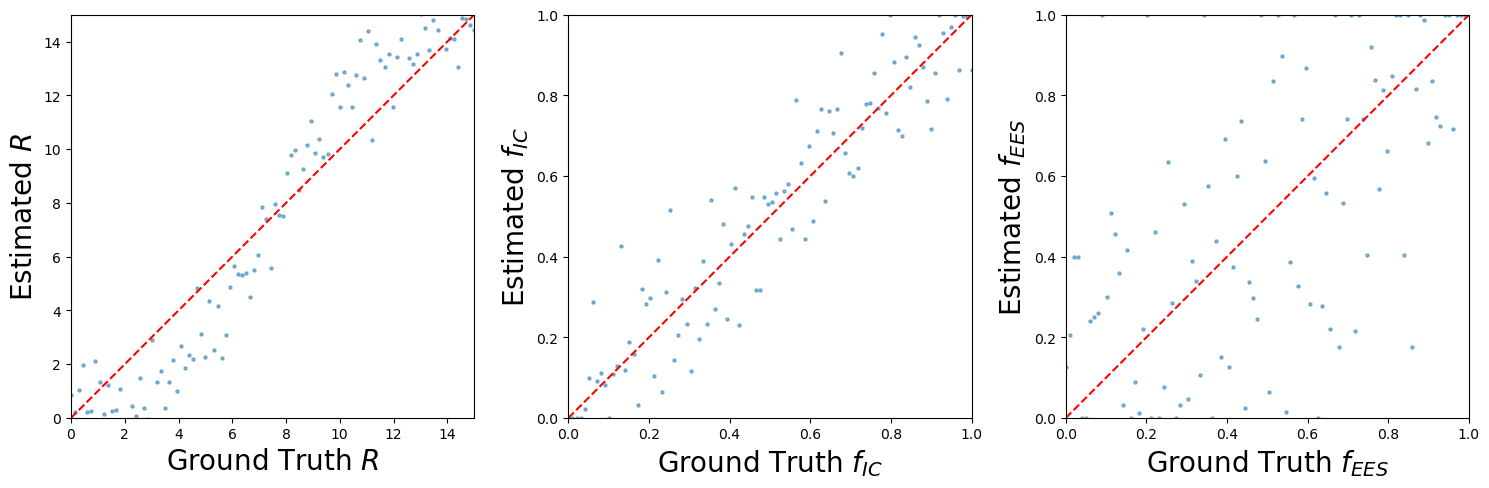

In [102]:
limits = [[0, 15], [0, 1], [0, 1]]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Parameters to plot (Ground truth and estimated values)
params_to_plot = [
    (x1, y1, '$R$'),
    (x2, y2, '$f_{IC}$'),
    (x3, y3, '$f_{EES}$')
]

# Loop through axes and parameters to plot
for ax, (gt, est, label), lim in zip(axes, params_to_plot, limits):
    ax.scatter(gt, est, s=5, alpha=0.5)
    ax.plot(lim, lim, 'r--')
    ax.set_xlabel(f'Ground Truth {label}', fontsize=20)
    ax.set_ylabel(f'Estimated {label}', fontsize=20)
    
    # Apply the same limit for both axes
    ax.set_xlim(lim)  # x-axis limit
    ax.set_ylim(lim)  # y-axis limit
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

In [103]:
mse_values = []
bias_values = []
variance_values = []
pearson_values = []

groundtruth_values = [x1, x2, x3]
estimated_values = [y1, y2, y3]

# Compute metrics for each parameter
for gt, est in zip(groundtruth_values, estimated_values):
    gt_flat = gt.flatten()
    est_flat = est.flatten()

    # MSE
    mse = mean_squared_error(gt_flat, est_flat)

    # Bias (Mean Difference)
    bias = np.mean(est_flat - gt_flat)

    # Variance (of the estimation error)
    variance = np.var(est_flat - gt_flat)

    # Pearson Correlation Coefficient
    pearson_corr, _ = pearsonr(gt_flat, est_flat)

    # Store results
    mse_values.append(mse)
    bias_values.append(bias)
    variance_values.append(variance)
    pearson_values.append(pearson_corr)

param_names = ['Radius', '$f_{IC}$', '$f_{EES}$']
# Display results
for i, param in enumerate(param_names):
    print(f"Parameter: {param}")
    print(f"  MSE: {mse_values[i]:.6f}")
    print(f"  Bias: {bias_values[i]:.6f}")
    print(f"  Variance: {variance_values[i]:.6f}")
    print(f"  Pearson Correlation: {pearson_values[i]:.6f}\n")

Parameter: Radius
  MSE: 2.746732
  Bias: -0.103847
  Variance: 2.735948
  Pearson Correlation: 0.965716

Parameter: $f_{IC}$
  MSE: 0.011433
  Bias: 0.005418
  Variance: 0.011403
  Pearson Correlation: 0.936257

Parameter: $f_{EES}$
  MSE: 0.086794
  Bias: 0.010311
  Variance: 0.086687
  Pearson Correlation: 0.593322

